# Stateful signal pipeline

Самостоятельный production-shaped pipeline без зависимости от research notebook и его артефактов:

`новые данные → update_models_if_due → get_signal → filter_signal → final backtest`.

Исторический прогон ниже буквально воспроизводит ежедневную production-последовательность. Rule-движки переоптимизируют только concrete thresholds внутри уже выбранной архитектуры и cadence. ML-движки используют фиксированный `HistGradientBoosting`, ежегодное переобучение и калибровку probability threshold на прошлом validation-окне. Будущие targets доступны только после созревания горизонта.

In [1]:
from datetime import date
from pathlib import Path
import json
import sys

import pandas as pd

candidate_roots = [Path.cwd(), Path.cwd() / 'prod', Path.cwd().parent]
PROJECT_ROOT = next((p.resolve() for p in candidate_roots if (p / 'src').is_dir()), None)
if PROJECT_ROOT is None:
    raise RuntimeError('Не найден корень репозитория с папкой src')
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.cbr_loader import CURRENCIES, load_cbr_history
from src.features import build_features
from src.market_data import build_daily_market_panel
from src.meta_model import (
    ConfidenceFilterConfig,
    build_meta_candidates,
    confidence_filter_meta_model,
    fit_logistic_meta_model,
    logistic_meta_model,
    run_meta_model,
)
from src.meta_arbiter import fit_meta_arbiter, run_meta_arbiter
from src.outcomes import add_future_outcomes
from src.production_config import (
    FIXED_INDICATORS, INDICATOR_SPACES, RULE_MIN_SIGNALS_PER_WEEK,
    RULE_CONFIDENCE_WINDOW_MONTHS,
    ML_CONFIG, ML_FEATURE_NAMES, ML_MIN_SIGNALS_PER_WEEK,
    ML_MODEL_TYPE, ML_POOLING_MODE, ML_RETRAIN_MONTHS, ML_VALIDATION_MONTHS,
    PRODUCTION_CURRENCIES, PRODUCTION_FIRST_SCORE_DATE,
    PRODUCTION_HORIZONS, PRODUCTION_TARGET_FAMILIES, TRAIN_WINDOW_MONTHS,
    fixed_indicator_registry,
)
from src.production_pipeline import (
    engine_state_registry, filter_signal, get_signal, initialize_engine_states,
    replay_engine_signals, save_engine_states,
)
from src.signal_backtest import backtest_signal_stream, build_evaluation_universe
from src.signal_contract import calibrate_rule_confidence_from_oos
from src.visualization import plot_benefit_distribution, plot_oos_uplift, plot_signal_series
from src.targets import build_targets

START_DATE = date(2018, 1, 1)
END_DATE = date.today()
RAW_DIR = PROJECT_ROOT / 'data' / 'raw' / 'cbr'

# Base OOS начинается в 2020. Архитектуры выбираются только до 2024,
# 2024 используется для meta-validation,
# а финальный backtest всей связки начинается в 2025.
BASE_OOS_START = pd.Timestamp(PRODUCTION_FIRST_SCORE_DATE)
META_TRAIN_END = pd.Timestamp('2025-01-01')
FINAL_BACKTEST_START = pd.Timestamp('2025-01-01')
META_VALIDATION_MONTHS = 12
META_MIN_SIGNALS_PER_WEEK = 1.0
META_MAX_SIGNALS_PER_WEEK = 2.0

META_MODEL_TYPE = 'confidence_filter'  # logistic_regression / hist_gradient_boosting / extra_trees
META_MAX_SIGNALS_PER_7D = 2
META_MIN_SUPPORT = 10
META_MIN_SOURCES = 1
META_COOLDOWN_OPTIONS = (0, 1, 2, 3, 4, 5, 6, 7)

## 1. Данные, causal features и targets

Features строки используют только сведения, доступные к её `available_at`. Future outcomes и targets нужны для исторического обучения и оценки; они не входят в JSON сигнала.

In [2]:
cbr_history = load_cbr_history(
    start_date=START_DATE,
    end_date=END_DATE,
    currencies=CURRENCIES,
    raw_dir=RAW_DIR,
)
rates = (
    cbr_history.pivot(index='available_at', columns='currency', values='normalized_rate')
    .reindex(columns=list(CURRENCIES))
    .sort_index()
)
rates.columns.name = None
market_panel = build_daily_market_panel(rates)
features = build_features(market_panel)
outcomes = add_future_outcomes(features, horizons=PRODUCTION_HORIZONS)
dataset, target_registry = build_targets(outcomes, horizons=PRODUCTION_HORIZONS)
scoring_data = dataset.loc[
    dataset['is_update_day'] & dataset['currency'].isin(PRODUCTION_CURRENCIES)
].copy()

pd.DataFrame({
    'first_available_at': [scoring_data['available_at'].min()],
    'last_available_at': [scoring_data['available_at'].max()],
    'rows': [len(scoring_data)],
})

,first_available_at,last_available_at,rows
0,2018-01-11,2026-09-06,10690


## 2. Реестр движков

Создаётся по одному rule- и одному ML-движку для каждой `currency × target_family × horizon`. Пустое состояние знает, когда впервые обучиться; после обучения в нём находятся конкретное правило либо веса модели, версия, даты train и следующий срок обновления.

In [3]:
production_rule_registry = fixed_indicator_registry()
states = initialize_engine_states(
    rule_configurations=FIXED_INDICATORS,
    target_registry=target_registry,
    currencies=PRODUCTION_CURRENCIES,
    target_families=PRODUCTION_TARGET_FAMILIES,
    first_score_date=BASE_OOS_START,
    train_months=TRAIN_WINDOW_MONTHS,
    ml_feature_names=ML_FEATURE_NAMES,
    ml_model_type=ML_MODEL_TYPE,
    ml_retrain_months=ML_RETRAIN_MONTHS,
    ml_pooling_mode=ML_POOLING_MODE,
)

assert len(states) == 2 * len(PRODUCTION_CURRENCIES) * len(PRODUCTION_TARGET_FAMILIES) * len(PRODUCTION_HORIZONS)
production_rule_registry

,currency,scenario,target_family,target,horizon,indicator,parameter_variants,retrain_months
0,AMD,GOOD_NOW,G0,target_g0_exact_min_h1d,1,level_low__OR__momentum_down,480,3
1,AMD,GOOD_NOW,G0,target_g0_exact_min_h3d,3,near_low__OR__momentum_down,360,3
2,AMD,GOOD_NOW,G0,target_g0_exact_min_h5d,5,trend_down,6,3
3,AMD,GOOD_NOW,G0,target_g0_exact_min_h10d,10,down_streak__OR__trend_down,24,3
4,AMD,GOOD_NOW,G0,target_g0_exact_min_h20d,20,momentum_down,20,3
5,KGS,GOOD_NOW,G0,target_g0_exact_min_h1d,1,level_low__OR__momentum_down,480,3
6,KGS,GOOD_NOW,G0,target_g0_exact_min_h3d,3,down_streak__OR__trend_down,24,3
7,KGS,GOOD_NOW,G0,target_g0_exact_min_h5d,5,down_streak__OR__trend_down,24,3
8,KGS,GOOD_NOW,G0,target_g0_exact_min_h10d,10,level_low__OR__trend_down,144,3
9,KGS,GOOD_NOW,G0,target_g0_exact_min_h20d,20,level_low__OR__momentum_up,480,3


## 3. Ежедневный исторический replay базовых движков

Для каждой даты выполняется один и тот же порядок:

1. `update_models_if_due` переобучает только просроченные движки и только на уже созревших targets из прошлого.
2. `get_signal` возвращает JSON-совместимый score всех движков, включая `signal=false` и технический статус.
3. Результатом является только неизменяемый `raw_signal_stream`; метамодель запускается отдельным этапом ниже.

Никакие итоговые метрики внутри этого цикла не оптимизируются.

In [4]:
replay = replay_engine_signals(
    scoring_data,
    states=states,
    first_score_date=BASE_OOS_START,
    indicator_spaces=INDICATOR_SPACES,
    rule_min_signals_per_week=RULE_MIN_SIGNALS_PER_WEEK,
    ml_validation_months=ML_VALIDATION_MONTHS,
    ml_min_signals_per_week=ML_MIN_SIGNALS_PER_WEEK,
    ml_model_type=ML_MODEL_TYPE,
    ml_model_config=ML_CONFIG,
    ml_pooling_mode=ML_POOLING_MODE,
)

## 4. Техническое состояние после replay

Это не таблица качества. Она отвечает только на эксплуатационные вопросы: какой артефакт сейчас активен, на каких зрелых данных обучен и когда должен обновиться. `training_audit` позволяет проверить, что обновления действительно происходили по заданному cadence.

In [5]:
current_engine_states = engine_state_registry(replay.states)
current_engine_states

,engine_id,engine_type,currency,target_family,target,horizon,architecture,pooling_mode,train_months,model_version,configuration_version,trained_at,trained_through,next_retrain_at,last_retrain_attempt_at,last_retrain_error,confidence,confidence_support,ready
0,ml:AMD:G0:h1,ml,AMD,G0,target_g0_exact_min_h1d,1,hist_gradient_boosting,per_currency,24,cadddea0bd6c4f59,10afe52706babfcf,2026-01-01,2025-12-28,2027-01-01,2026-01-01,None,0.577236,123,True
1,ml:AMD:G0:h3,ml,AMD,G0,target_g0_exact_min_h3d,3,hist_gradient_boosting,per_currency,24,65ad0f4507d0df01,10afe52706babfcf,2026-01-01,2025-12-28,2027-01-01,2026-01-01,None,0.297030,101,True
2,ml:AMD:G0:h5,ml,AMD,G0,target_g0_exact_min_h5d,5,hist_gradient_boosting,per_currency,24,7504f86fb6930b8b,10afe52706babfcf,2026-01-01,2025-12-26,2027-01-01,2026-01-01,None,0.220000,100,True
3,ml:AMD:G0:h10,ml,AMD,G0,target_g0_exact_min_h10d,10,hist_gradient_boosting,per_currency,24,4591982b38511a11,10afe52706babfcf,2026-01-01,2025-12-21,2027-01-01,2026-01-01,None,0.130000,100,True
4,ml:AMD:G0:h20,ml,AMD,G0,target_g0_exact_min_h20d,20,hist_gradient_boosting,per_currency,24,20ef58cc558ac533,10afe52706babfcf,2026-01-01,2025-12-11,2027-01-01,2026-01-01,None,0.062500,96,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,rule:UZS:W1:h1,rule,UZS,W1,target_w1_lowpct_0p15_deterioration_75bps_h1d,1,momentum_down__OR__down_streak,per_currency,24,8e15ef2c3335023b,7a67cd48d182da2e,2026-01-01,2025-12-28,2027-01-01,2026-01-01,None,0.090047,211,True
96,rule:UZS:W1:h3,rule,UZS,W1,target_w1_lowpct_0p15_deterioration_75bps_h3d,3,momentum_down__OR__trend_down,per_currency,24,4e882eee2c6931ef,c79c9476af3a453b,2026-07-01,2026-06-27,2026-10-01,2026-07-01,None,0.166667,216,True
97,rule:UZS:W1:h5,rule,UZS,W1,target_w1_lowpct_0p15_deterioration_75bps_h5d,5,momentum_down,per_currency,24,e3a5ba1b3bf76db0,57dd3738f575aee7,2026-07-01,2026-06-25,2026-10-01,2026-07-01,None,0.204444,225,True
98,rule:UZS:W1:h10,rule,UZS,W1,target_w1_lowpct_0p15_deterioration_75bps_h10d,10,momentum_down,per_currency,24,f51ba038d0ac7085,57dd3738f575aee7,2026-01-01,2025-12-21,2027-01-01,2026-01-01,None,0.251082,231,True


In [6]:
replay.training_audit[[
    'as_of', 'engine_id', 'fitted', 'trained_through', 'next_retrain_at'
]].tail(20)

,as_of,engine_id,fitted,trained_through,next_retrain_at
1753,2026-07-01,rule:AMD:W1:h3,True,2026-06-27,2027-01-01
1754,2026-07-01,rule:AMD:W1:h5,True,2026-06-25,2026-10-01
1755,2026-07-01,rule:KGS:W1:h1,True,2026-06-28,2026-10-01
1756,2026-07-01,rule:KGS:W1:h3,True,2026-06-27,2026-10-01
1757,2026-07-01,rule:KGS:W1:h5,True,2026-06-25,2026-10-01
1758,2026-07-01,rule:KGS:W1:h10,True,2026-06-20,2026-10-01
1759,2026-07-01,rule:KGS:W1:h20,True,2026-06-10,2027-01-01
1760,2026-07-01,rule:KZT:W1:h1,True,2026-06-28,2026-10-01
1761,2026-07-01,rule:KZT:W1:h3,True,2026-06-27,2026-10-01
1762,2026-07-01,rule:KZT:W1:h5,True,2026-06-25,2026-10-01


## 5. Единый арбитр и policy

`META_MODEL_TYPE` выбирает confidence filter, Logistic Regression, HistGradientBoosting или ExtraTrees через один API. Rule confidence — rolling OOS precision за 24 месяца, ML confidence — текущий `predict_proba`. Пороги и cooldown выбираются только на validation 2024 с жёстким лимитом не более двух сигналов по валюте за любые семь дней; с 2025 применяется уже замороженная конфигурация.

In [7]:
raw_signal_stream = replay.raw_signals.copy()
raw_signal_stream['available_at'] = pd.to_datetime(raw_signal_stream['available_at'])

all_evaluation_universe = build_evaluation_universe(
    scoring_data,
    target_registry=target_registry,
    target_families=PRODUCTION_TARGET_FAMILIES,
    currencies=PRODUCTION_CURRENCIES,
    start_date=BASE_OOS_START,
)
raw_signal_stream = calibrate_rule_confidence_from_oos(
    raw_signal_stream,
    evaluation_universe=all_evaluation_universe,
    window_months=RULE_CONFIDENCE_WINDOW_MONTHS,
)
meta_candidates = build_meta_candidates(raw_signal_stream)
meta_keys = ['available_at', 'currency', 'scenario', 'target_family', 'target', 'horizon']
meta_training_data = meta_candidates.merge(
    all_evaluation_universe[meta_keys + ['target_value']],
    on=meta_keys, how='left', validate='many_to_one',
).dropna(subset=['target_value'])

# Подхватываем изменения backtest/meta-кода без повторного replay движков.
from importlib import reload
import src.signal_backtest as signal_backtest_module
import src.meta_arbiter as meta_arbiter_module
reload(signal_backtest_module)
reload(meta_arbiter_module)

fitted_meta_arbiter, meta_validation_leaderboard = meta_arbiter_module.fit_meta_arbiter(
    meta_training_data,
    evaluation_universe=all_evaluation_universe,
    model_type=META_MODEL_TYPE,
    train_end=META_TRAIN_END,
    validation_months=META_VALIDATION_MONTHS,
    min_signals_per_week=META_MIN_SIGNALS_PER_WEEK,
    max_signals_per_week=META_MAX_SIGNALS_PER_WEEK,
    max_signals_per_7d=META_MAX_SIGNALS_PER_7D,
    min_support=META_MIN_SUPPORT,
    min_sources=META_MIN_SOURCES,
    cooldown_options=META_COOLDOWN_OPTIONS,
)

final_raw_signal_stream = raw_signal_stream.loc[
    raw_signal_stream["available_at"].ge(FINAL_BACKTEST_START)
].copy()

final_signal_stream = meta_arbiter_module.run_meta_arbiter(
    final_raw_signal_stream, fitted_meta_arbiter
)

# Production-style вызов для последней даты с историей policy.
latest_date = raw_signal_stream["available_at"].max()

latest_raw_vector = raw_signal_stream.loc[
    raw_signal_stream["available_at"].eq(latest_date)
].to_dict(orient="records")

latest_filtered_events = meta_arbiter_module.run_meta_arbiter(
    pd.DataFrame(latest_raw_vector),
    fitted_meta_arbiter,
    policy_history=final_signal_stream.loc[
        final_signal_stream['available_at'].lt(latest_date)
    ],
).to_dict(orient='records')

print(f"Raw engine scores: {len(latest_raw_vector)}")
print(f"Filtered events: {len(latest_filtered_events)}")

display(meta_validation_leaderboard.head(10))
fitted_meta_arbiter

Raw engine scores: 100
Filtered events: 3


,rule_threshold,ml_threshold,decision_threshold,cooldown_days,frequency_ok,macro_lift,min_currency_lift,mean_precision,mean_signals_per_week,selected
0,0.6,0.8,NaN,0,True,3.247351,2.826879,0.536426,1.060845,True
1,0.6,0.9,NaN,2,False,4.432741,3.950866,0.557111,0.516620,False
2,0.6,0.9,NaN,0,False,4.345049,3.716924,0.545076,0.583662,False
3,0.6,0.9,NaN,1,False,4.345049,3.716924,0.545076,0.583662,False
4,0.6,0.9,NaN,7,False,4.253836,2.957060,0.564995,0.358873,False
5,0.6,0.9,NaN,3,False,4.238894,3.592885,0.545846,0.485070,False
6,0.6,0.9,NaN,4,False,4.089033,3.891039,0.526485,0.457465,False
7,0.6,0.9,NaN,6,False,3.962028,2.984276,0.529676,0.386479,False
8,0.6,0.9,NaN,5,False,3.882010,2.922010,0.522271,0.394366,False
9,0.6,0.8,NaN,1,True,3.247351,2.826879,0.536426,1.060845,False


FittedMetaArbiter(model_type='confidence_filter', estimator=None, decision_threshold=None, filter_config=ConfidenceFilterConfig(min_confidence=0.0, min_support=10, min_sources=1, rule_min_confidence=0.6, ml_min_confidence=0.8), policy_config=SignalPolicyConfig(cooldown_days=0, max_signals_per_7d=2), feature_names=('rule_signal', 'rule_raw_score', 'rule_confidence', 'rule_support', 'rule_lift', 'ml_signal', 'ml_probability', 'ml_margin', 'ml_confidence', 'ml_support', 'ml_lift', 'source_count', 'agreement', 'currency', 'target_family', 'horizon'), trained_at=Timestamp('2025-01-01 00:00:00'), trained_through=Timestamp('2024-12-30 00:00:00'), validation_start=Timestamp('2024-01-01 00:00:00'), validation_end=Timestamp('2025-01-01 00:00:00'), validation_macro_lift=3.247350922830661, validation_min_currency_lift=2.8268790095137, validation_mean_signals_per_week=1.0608450704225352)

## 6. Единственная итоговая оценка — после метамодели

`signal_backtest_summary` считает результаты конечных событий выбранной метамодели начиная с `FINAL_BACKTEST_START = 2025-01-01`. В отчёте ровно 80 строк: 5 по валютам, 25 по валютам и горизонтам, 50 по валютам, горизонтам и target family. На агрегированных уровнях случайная база взвешивается по фактическому составу выданных target/horizon-сигналов. Промежуточные rule/ML scores и validation-метрики не являются финальным backtest.

In [8]:
evaluation_universe = build_evaluation_universe(
    scoring_data,
    target_registry=target_registry,
    target_families=PRODUCTION_TARGET_FAMILIES,
    currencies=PRODUCTION_CURRENCIES,
    start_date=FINAL_BACKTEST_START,
)
# Повторный импорт позволяет пересчитать только эту ячейку после обновления src,
# не перезапуская тяжёлый replay индикаторов и ML.
from importlib import reload
import src.signal_backtest as signal_backtest_module
reload(signal_backtest_module)

signal_backtest_summary, signal_backtest_rows = signal_backtest_module.backtest_signal_stream(
    final_signal_stream,
    evaluation_universe=evaluation_universe,
)
signal_backtest_summary

,scope,currency,horizon,target_family,observations,positive_count,signal_count,true_positive,false_positive,precision,random_precision,lift,calendar_weeks,signals_per_week,mean_benefit_bps,random_mean_benefit_bps,benefit_uplift_bps,positive_benefit_rate
0,currency,AMD,ALL,ALL,4056,425,107,41,66,0.383178,0.155543,2.463482,86.142857,1.242123,58.344859,2.389886,55.954972,0.757009
1,currency,KGS,ALL,ALL,4056,416,100,26,74,0.260000,0.142352,1.826460,86.142857,1.160862,44.477191,3.305572,41.171619,0.710000
2,currency,KZT,ALL,ALL,4056,426,107,48,59,0.448598,0.161096,2.784667,86.142857,1.242123,52.992179,4.843502,48.148677,0.841121
3,currency,TJS,ALL,ALL,4056,399,100,41,59,0.410000,0.150028,2.732820,86.142857,1.160862,54.604899,2.236343,52.368556,0.710000
4,currency,UZS,ALL,ALL,4056,435,89,31,58,0.348315,0.169280,2.057629,86.142857,1.033167,51.637276,1.997715,49.639561,0.786517
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,currency+horizon+target_family,UZS,5,W1,407,48,6,0,6,0.000000,0.117936,0.000000,85.285714,0.070352,14.536806,1.180951,13.355855,0.666667
76,currency+horizon+target_family,UZS,10,G0,404,16,2,1,1,0.500000,0.039604,12.625000,84.857143,0.023569,104.799436,2.333043,102.466394,1.000000
77,currency+horizon+target_family,UZS,10,W1,404,50,14,5,9,0.357143,0.123762,2.885714,84.857143,0.164983,9.633496,2.333043,7.300453,0.642857
78,currency+horizon+target_family,UZS,20,G0,397,9,3,0,3,0.000000,0.022670,0.000000,83.285714,0.036021,217.931145,6.331283,211.599862,1.000000


## 7. Опциональное сохранение production state

На реальном сервисе состояние сохраняется после успешного обновления и загружается при старте процесса. В notebook запись намеренно выключена: раскомментируйте только если нужен локальный snapshot.

In [9]:
# STATE_PATH = PROJECT_ROOT / 'models' / 'engine_states.joblib'
# save_engine_states(replay.states, STATE_PATH)

# 8. Визуализации

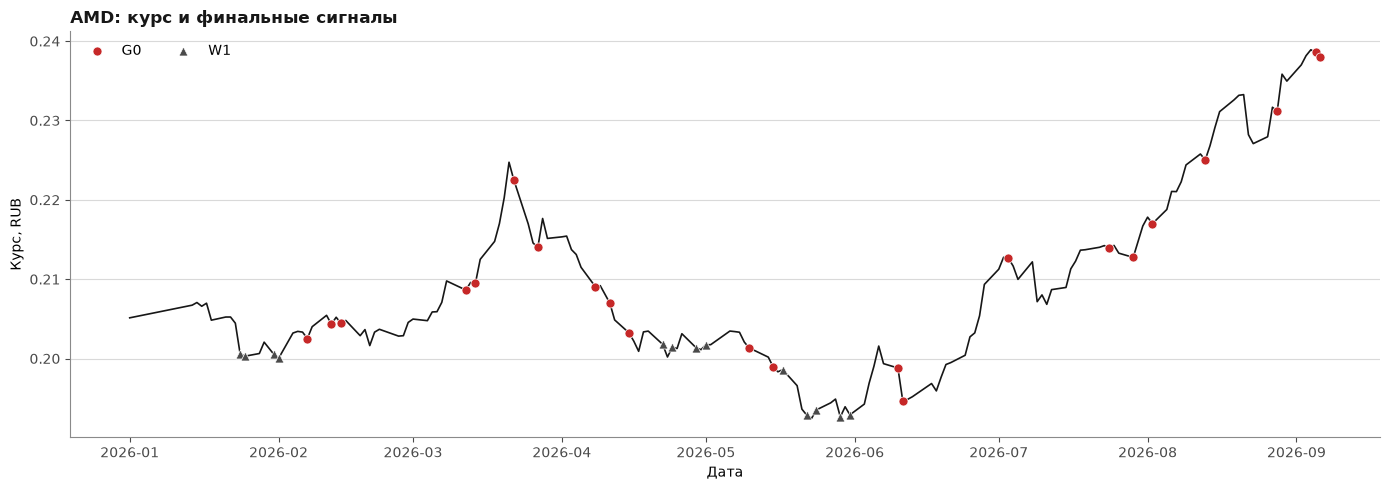

In [10]:
# Отдельная секция графика конечных сигналов после метамодели.
import matplotlib.pyplot as plt
PRESENTATION_CURRENCY = 'AMD'
plot_signal_series(
    scoring_data,
    final_signal_stream,
    currency=PRESENTATION_CURRENCY,
    start_date="2026-01-01",
)
plt.tight_layout()
plt.show()

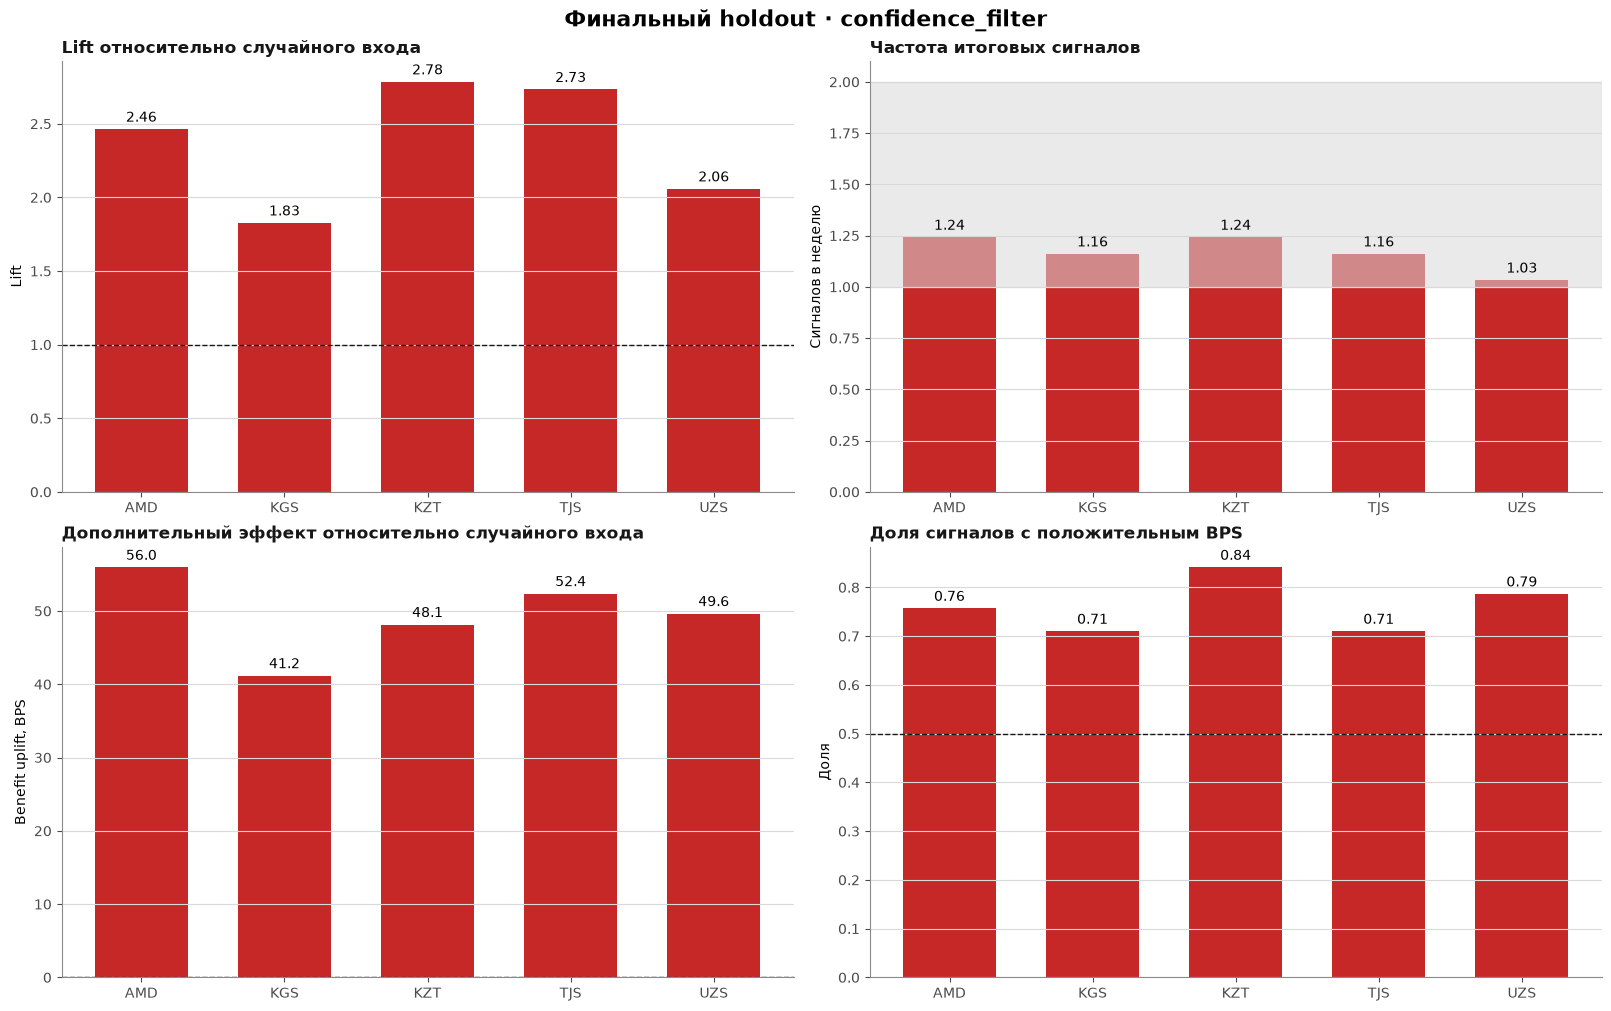

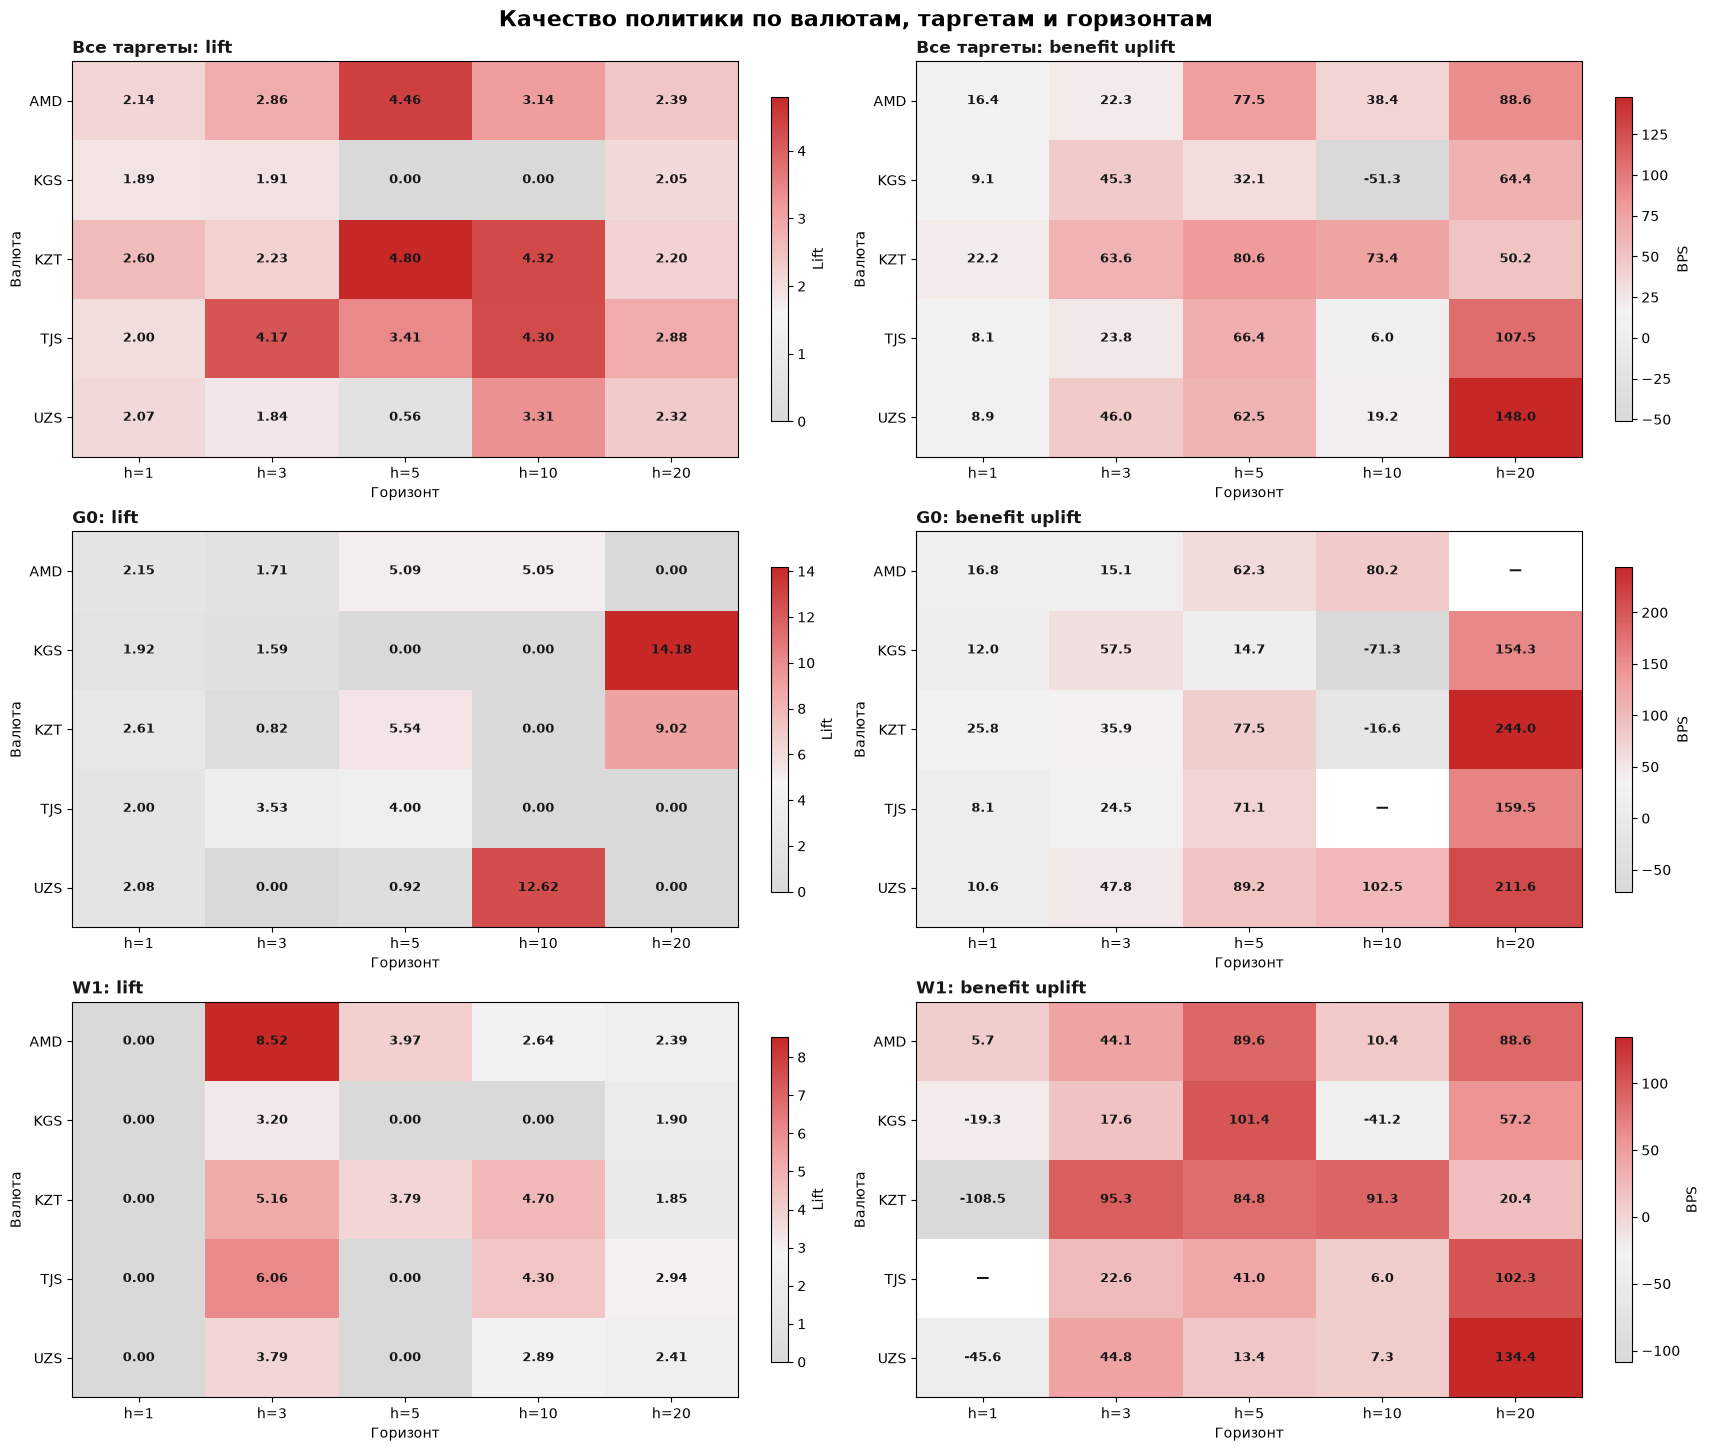

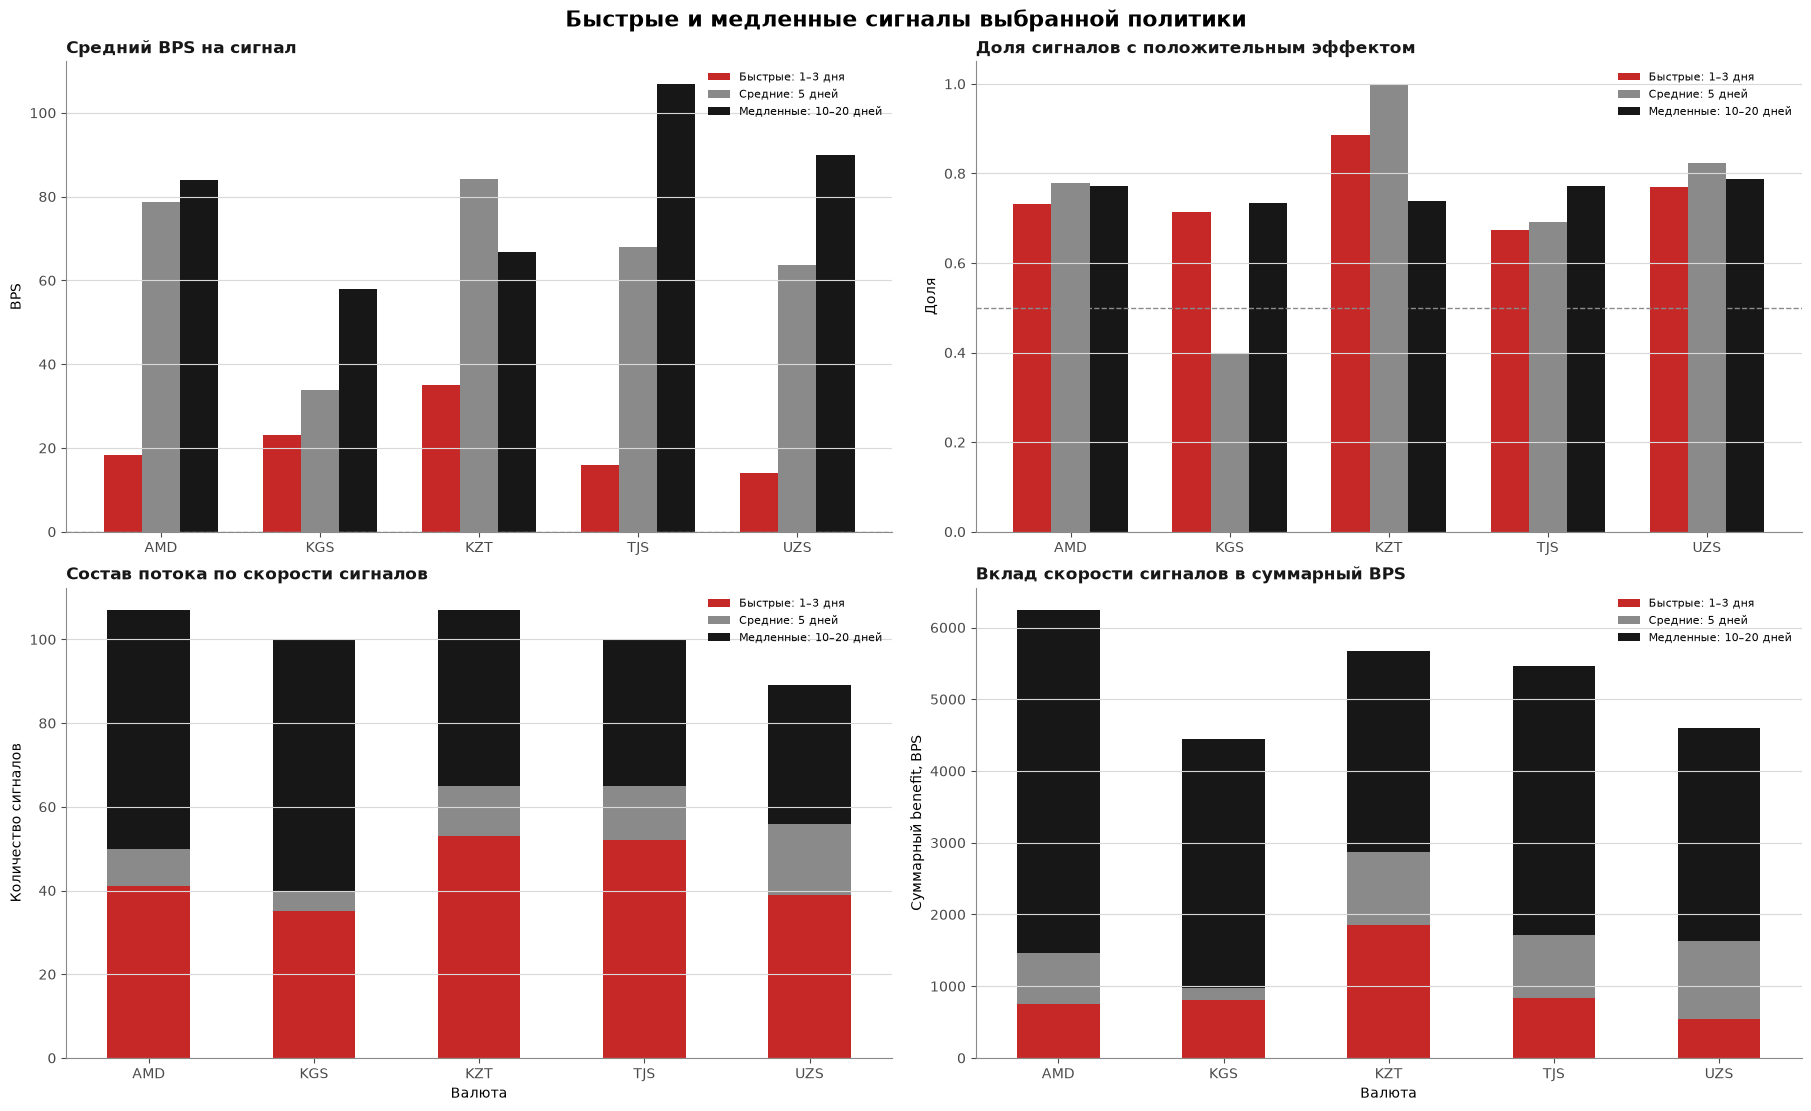

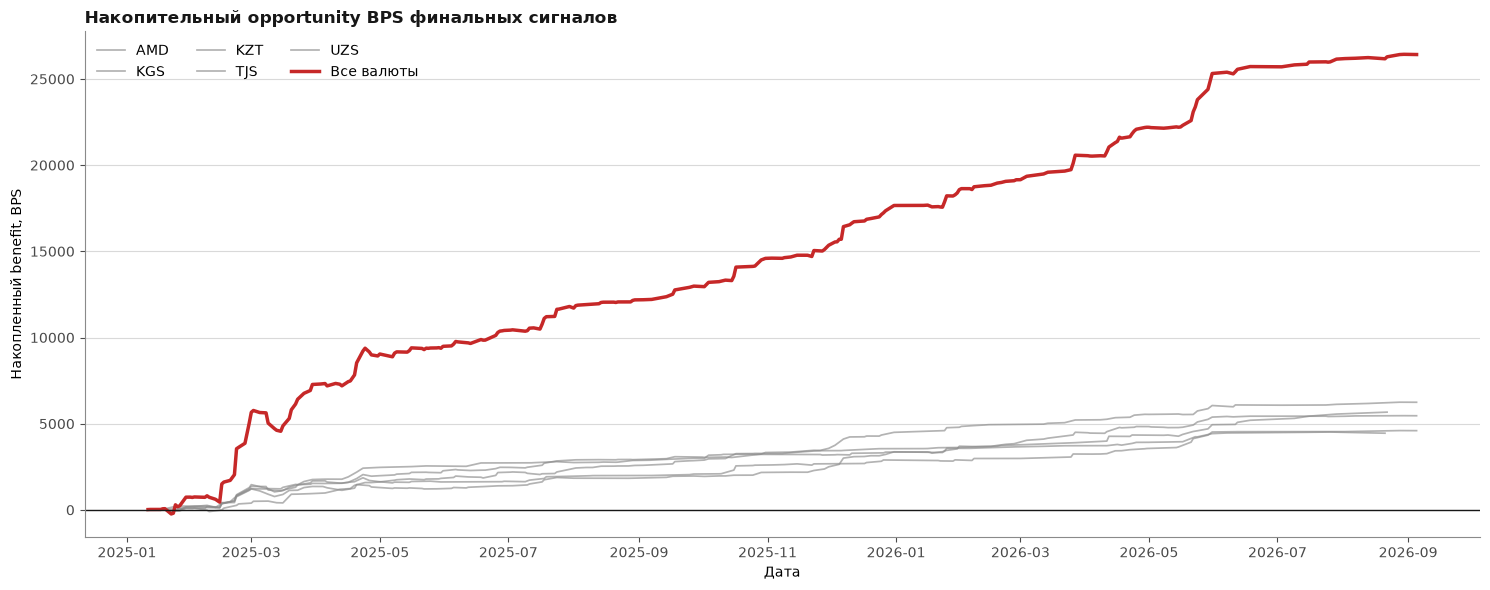

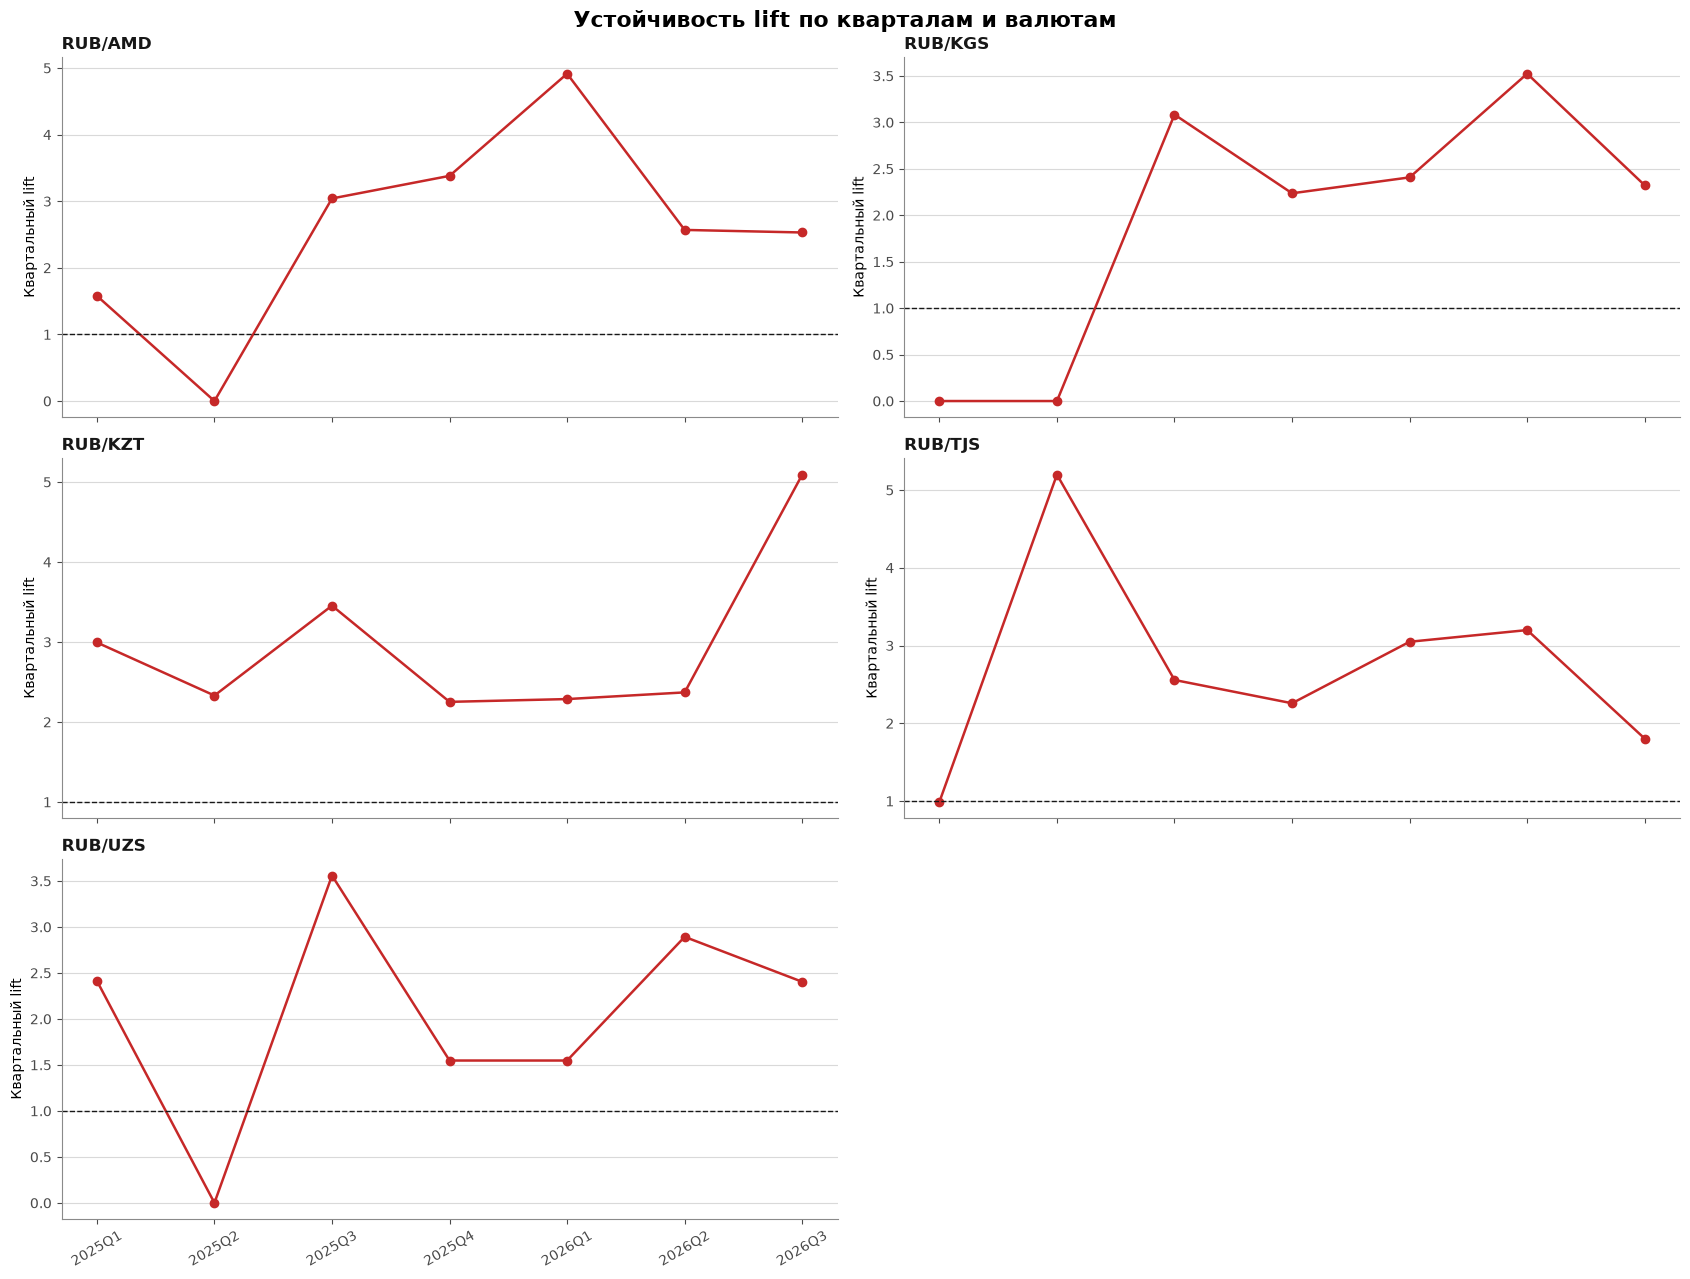

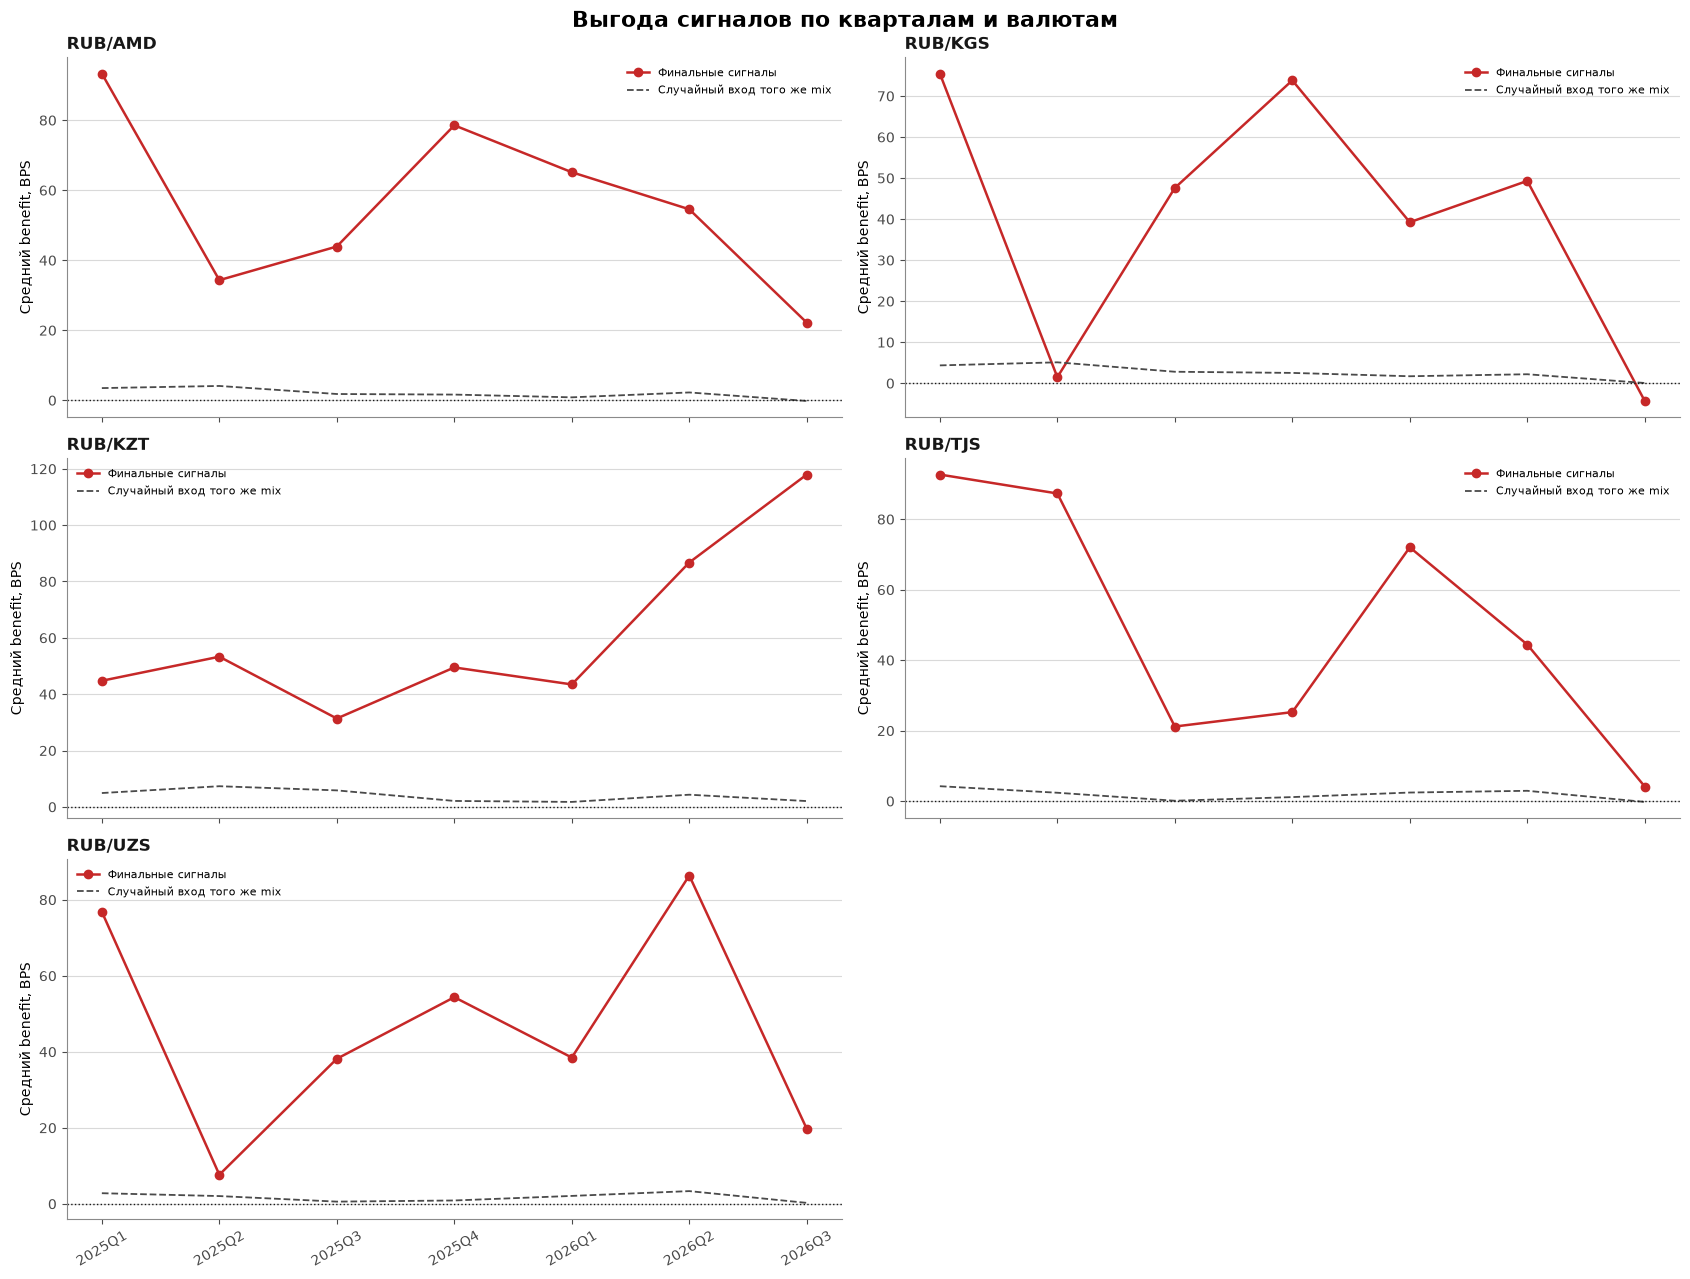

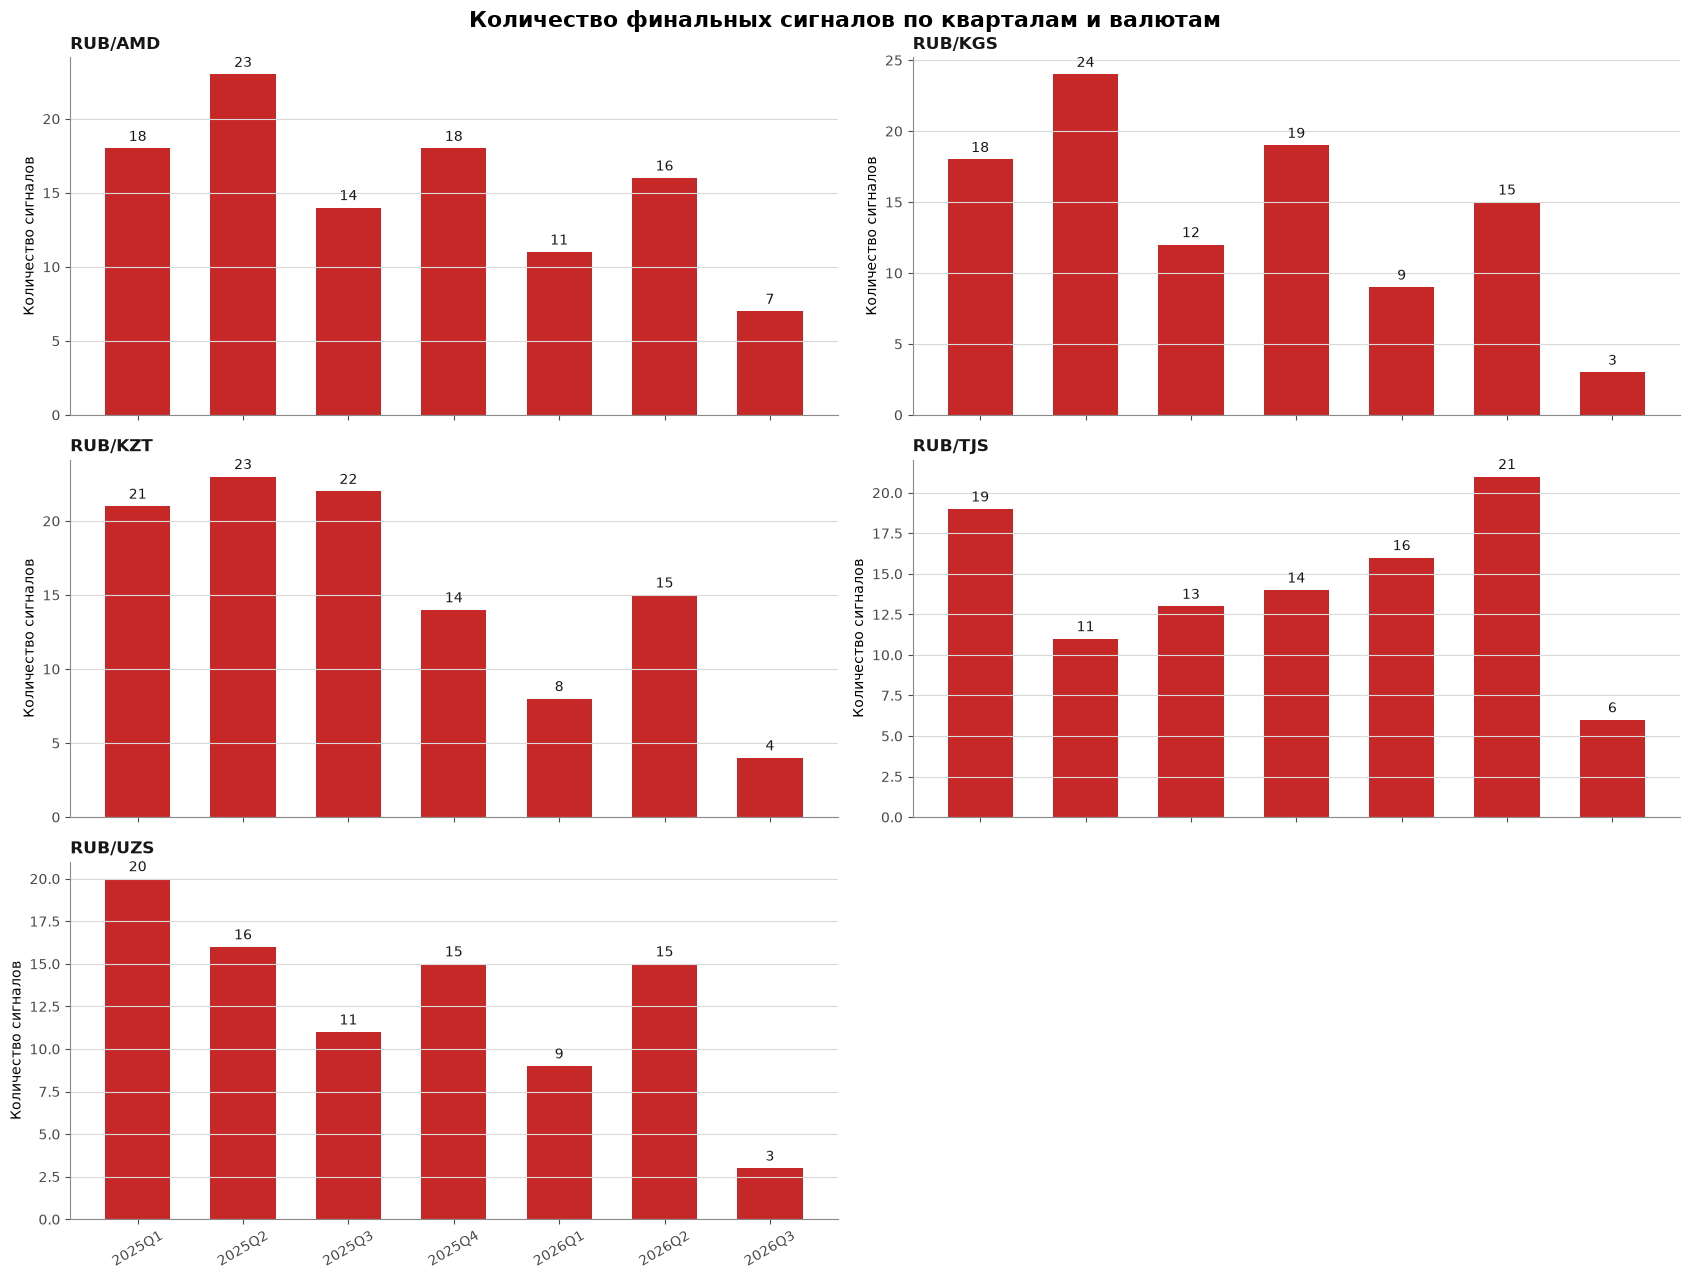

,currency,lift,lift_ci_low,lift_ci_high,mean_benefit_bps,mean_bps_ci_low,mean_bps_ci_high
0,ALL,2.392,1.945,2.854,52.519,39.865,65.882
1,AMD,2.463,1.629,3.307,58.345,41.510,77.387
2,KGS,1.826,0.989,2.708,44.477,25.083,64.658
3,KZT,2.785,2.186,3.338,52.992,37.471,69.680
4,TJS,2.733,1.923,3.655,54.605,34.560,74.318
5,UZS,2.058,1.472,2.705,51.637,31.848,73.436


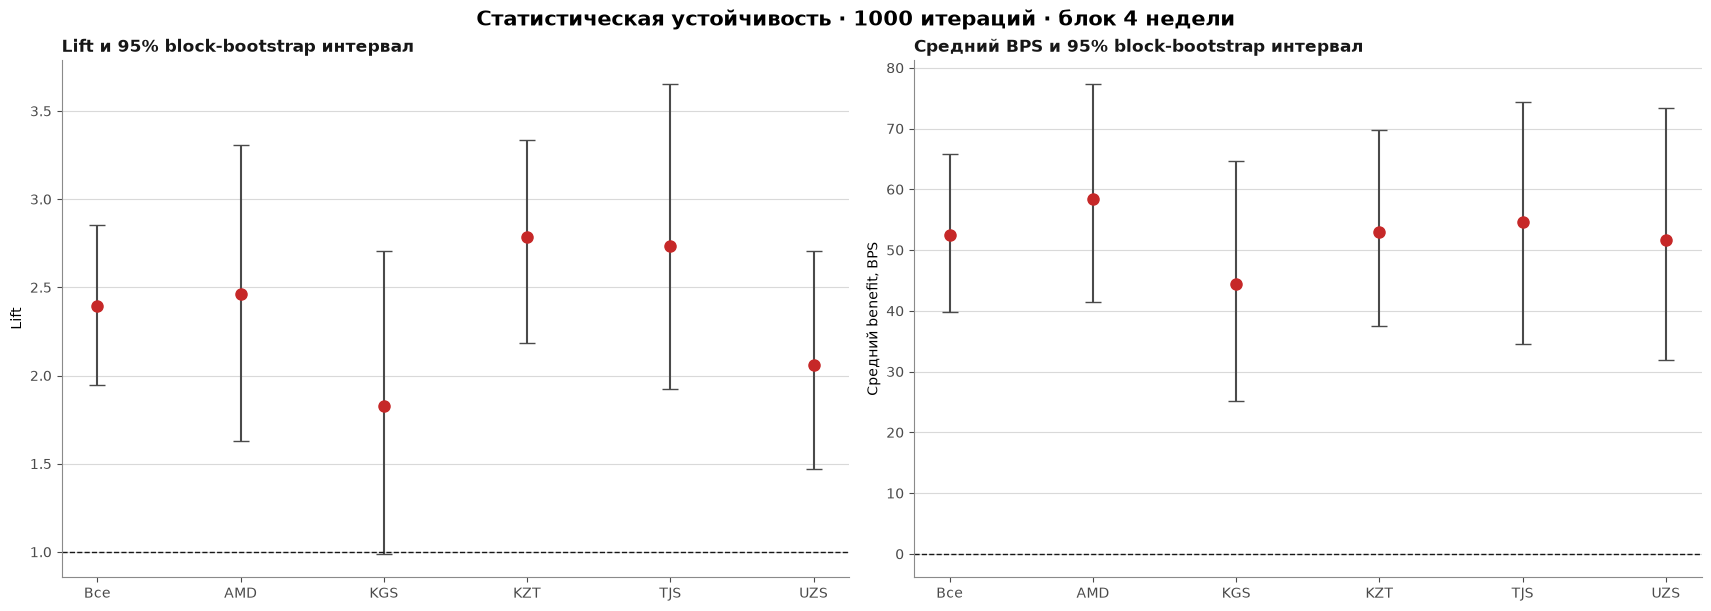

In [14]:
# Графики адаптированы из анализа Александра для одной выбранной политики.
# Ячейка использует уже рассчитанные summary/rows: replay и обучение повторять не нужно.
from importlib import reload
import matplotlib.pyplot as plt
import src.visualization as visualization_module
reload(visualization_module)

policy_name = getattr(fitted_meta_arbiter, 'model_type', 'selected_policy')

visualization_module.plot_policy_currency_overview(
    signal_backtest_summary, policy_name=policy_name,
)
plt.show()

visualization_module.plot_policy_horizon_heatmaps(signal_backtest_summary)
plt.show()

visualization_module.plot_policy_speed_analysis(signal_backtest_rows)
plt.show()

visualization_module.plot_policy_cumulative_bps(signal_backtest_rows)
plt.show()

visualization_module.plot_policy_quarterly_stability(signal_backtest_rows)
plt.show()

visualization_module.plot_policy_quarterly_benefit(signal_backtest_rows)
plt.show()

visualization_module.plot_policy_quarterly_signal_count(signal_backtest_rows)
plt.show()

bootstrap_figure, policy_bootstrap_summary = (
    visualization_module.plot_policy_bootstrap_intervals(
        signal_backtest_rows, repeats=1000, block_weeks=4, seed=42,
    )
)
display(policy_bootstrap_summary.round(3))
plt.show()